In [2]:
import pandas as pd
import numpy as np
import random
from typing import Set, Tuple, Dict, Any, List
from pathlib import Path
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
plt.style.use("./rw_visualization.mplstyle")

In [3]:
data_path = Path("./signor")
data_oct_2018 = pd.read_csv(data_path / 'Oct2018_release.txt', sep='\t')
data_oct_2019 = pd.read_csv(data_path / 'Oct2019_release.txt', sep='\t')
data_oct_2020 = pd.read_csv(data_path / 'Oct2020_release.txt', sep='\t')
data_oct_2021 = pd.read_csv(data_path / 'Oct2021_release.txt', sep='\t')
data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')
data_oct_2023 = pd.read_csv(data_path / 'Oct2023_release.txt', sep='\t')
data_oct_2024 = pd.read_csv(data_path / 'Oct2024_release.txt', sep='\t')
data_jul_2025 = pd.read_csv(data_path / 'Jul2025_release.txt', sep='\t')

/var/folders/zs/wmj4gqkd279brvy8rl7k52qh0000gp/T/ipykernel_90130/548278540.py:6: DtypeWarning: Columns (10,11,15,16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  data_oct_2022 = pd.read_csv(data_path / 'Oct2022_release.txt', sep='\t')


Text(0, 0.5, 'Number of edges')

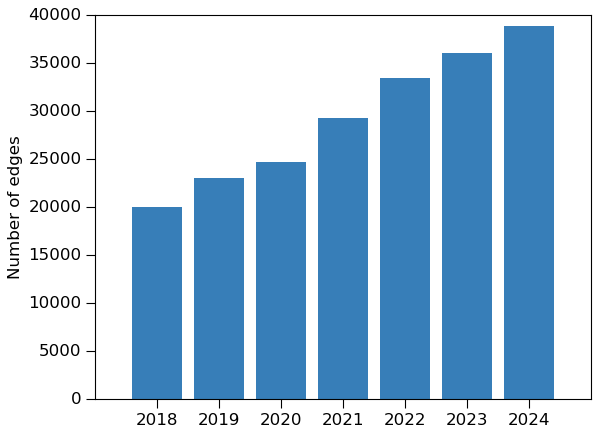

In [4]:
plt.bar([0, 1, 2, 3, 4, 5, 6], [data_oct_2018.shape[0], data_oct_2019.shape[0], data_oct_2020.shape[0], data_oct_2021.shape[0], data_oct_2022.shape[0], data_oct_2023.shape[0], data_oct_2024.shape[0]])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['2018', '2019', '2020', '2021', '2022', '2023', '2024'])
plt.ylabel('Number of edges')


# Consider only SIGNOR_ID

In [5]:
oct_2018_ids = data_oct_2018.SIGNOR_ID
oct_2019_ids = data_oct_2019.SIGNOR_ID
oct_2020_ids = data_oct_2020.SIGNOR_ID
oct_2021_ids = data_oct_2021.SIGNOR_ID
oct_2022_ids = data_oct_2022.SIGNOR_ID
oct_2023_ids = data_oct_2023.SIGNOR_ID
oct_2024_ids = data_oct_2024.SIGNOR_ID
jul_2025_ids = data_jul_2025.SIGNOR_ID

# Set of unique edges
oct_2018_ids_set = set(oct_2018_ids)
oct_2019_ids_set = set(oct_2019_ids)
oct_2020_ids_set = set(oct_2020_ids)
oct_2021_ids_set = set(oct_2021_ids)
oct_2022_ids_set = set(oct_2022_ids)
oct_2023_ids_set = set(oct_2023_ids)
oct_2024_ids_set = set(oct_2024_ids)
jul_2025_ids_set = set(jul_2025_ids)

In [6]:
removed_ids_2018_2019 = oct_2018_ids_set - oct_2018_ids_set.intersection(oct_2019_ids_set)
removed_ids_2019_2020 = oct_2019_ids_set - oct_2019_ids_set.intersection(oct_2020_ids_set)
removed_ids_2020_2021 = oct_2020_ids_set - oct_2020_ids_set.intersection(oct_2021_ids_set)
removed_ids_2021_2022 = oct_2021_ids_set - oct_2021_ids_set.intersection(oct_2022_ids_set)
removed_ids_2022_2023 = oct_2022_ids_set - oct_2022_ids_set.intersection(oct_2023_ids_set)
removed_ids_2023_2024 = oct_2023_ids_set - oct_2023_ids_set.intersection(oct_2024_ids_set)
removed_ids_2024_2025 = oct_2024_ids_set - oct_2024_ids_set.intersection(jul_2025_ids_set)

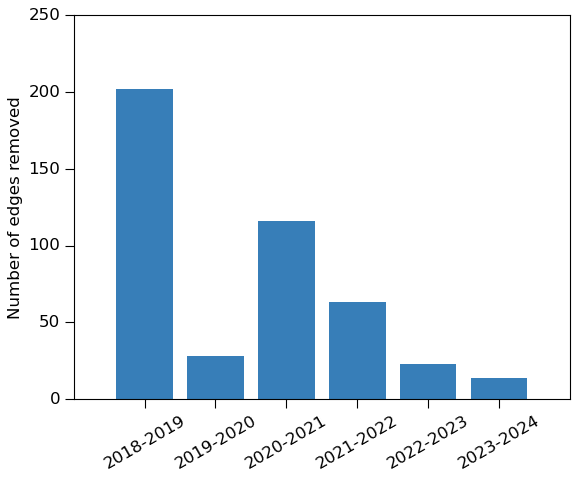

In [7]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_ids_2018_2019), len(removed_ids_2019_2020), len(removed_ids_2020_2021), len(removed_ids_2021_2022), len(removed_ids_2022_2023), len(removed_ids_2023_2024)])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

# Consider also the source and target name

In [8]:
def find_reassigned_edges(removed_ids: set, old_data: pd.DataFrame, new_data: pd.DataFrame, consider_interaction: bool = True) -> List[Dict[str, Any]]:
    """
    Validate if edges marked as removed actually still exist in new data with different IDs.
    
    Args:
        removed_ids: Set of SIGNOR_IDs that appear to be removed
        old_data: DataFrame containing the old release data
        new_data: DataFrame containing the new release data
        consider_interaction: Whether to match on interaction type as well
    
    Returns:
        List of edges that still exist in new data despite being marked as removed
    """
    reassigned_edges = []
    
    for old_signor_id in removed_ids:
        # Step 1: Find the edge details in the old data using SIGNOR_ID
        if not pd.isna(old_signor_id):
            old_edge_row = old_data[old_data['SIGNOR_ID'] == old_signor_id]
        else:
            old_edge_row = old_data[old_data['SIGNOR_ID'].isna()]
        
        # Extract edge components from old data
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        effect_type = old_edge_row['EFFECT'].iloc[0]

        # Step 2: Check if the same edge exists in the new data
        if consider_interaction:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity) & 
                (new_data['EFFECT'] == effect_type)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'effect_type': effect_type,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
        else:
            matching_edges = new_data[
                (new_data['ENTITYA'] == source_entity) & 
                (new_data['ENTITYB'] == target_entity)
            ]
            
            if not matching_edges.empty:
                reassigned_edges.append({
                    'old_signor_id': old_signor_id,
                    'source_entity': source_entity,
                    'target_entity': target_entity,
                    'new_signor_id': matching_edges['SIGNOR_ID'].iloc[0]
                })
    
    return reassigned_edges

In [9]:
reassigned_edges = find_reassigned_edges(removed_ids_2018_2019, data_oct_2018, data_oct_2019, consider_interaction=False)
# There are plenty edges with different SIGNOR_ID from different years.
print(len(reassigned_edges))
print(reassigned_edges[:5])

176
[{'old_signor_id': 'SIGNOR-251465', 'source_entity': 'GRK3', 'target_entity': 'CCR5', 'new_signor_id': 'SIGNOR-251463'}, {'old_signor_id': 'SIGNOR-251438', 'source_entity': 'ACVR1', 'target_entity': 'SMAD1', 'new_signor_id': 'SIGNOR-60174'}, {'old_signor_id': 'SIGNOR-153408', 'source_entity': 'SMURF1', 'target_entity': 'SMAD5', 'new_signor_id': 'SIGNOR-195663'}, {'old_signor_id': 'SIGNOR-236629', 'source_entity': 'INS', 'target_entity': 'IRS1', 'new_signor_id': 'SIGNOR-236737'}, {'old_signor_id': 'SIGNOR-256023', 'source_entity': 'RIPK1', 'target_entity': 'MAP3K7', 'new_signor_id': 'SIGNOR-256022'}]


In [10]:
removed_ids_list = [removed_ids_2018_2019, removed_ids_2019_2020, removed_ids_2020_2021, removed_ids_2021_2022, removed_ids_2022_2023, removed_ids_2023_2024, removed_ids_2024_2025]
old_data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024]
new_data_list = [data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_jul_2025]

removed_edges_list = []
for i, removed_ids in enumerate(removed_ids_list):
    reassigned_edges = find_reassigned_edges(removed_ids, old_data_list[i], new_data_list[i], consider_interaction=False)
    # Delete the edges in the removed_ids that is in the reassigned_edges.
    for edge in reassigned_edges:
        if edge['old_signor_id'] in removed_ids:
            removed_ids.remove(edge['old_signor_id'])
    removed_edges_list.append(removed_ids)

In [25]:
removed_nums = [len(removed_ids) for removed_ids in removed_edges_list]
print('total removed edges:', sum(removed_nums))

total removed edges: 141


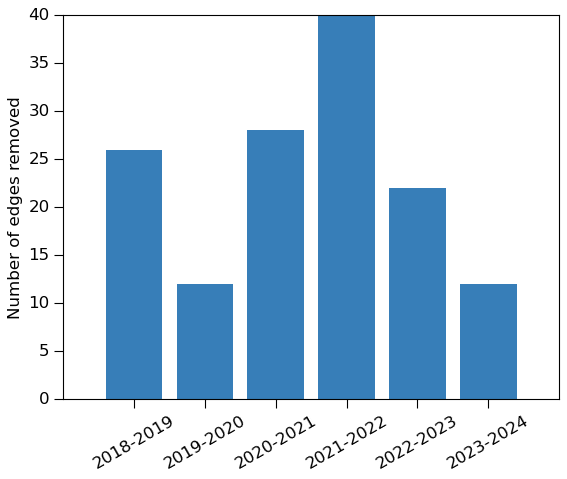

In [11]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_edges_list[0]), len(removed_edges_list[1]), len(removed_edges_list[2]), len(removed_edges_list[3]), len(removed_edges_list[4]), len(removed_edges_list[5])])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed')
plt.show()

# Remove the edges that one of the node is completely removed from the 2025 graph.

In [19]:
removed_edges_with_node_exist_in_2025_list = [s.copy() for s in removed_edges_list]
for i, removed_edges in enumerate(removed_edges_list):
    for removed_id in list(removed_edges):
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        source_entity = old_edge_row['ENTITYA'].iloc[0]
        target_entity = old_edge_row['ENTITYB'].iloc[0]
        if (source_entity not in set(data_jul_2025['ENTITYA']).union(set(data_jul_2025['ENTITYB']))) or (target_entity not in set(data_jul_2025['ENTITYA']).union(set(data_jul_2025['ENTITYB']))):
            print(f"source: {source_entity}, targes: {target_entity}")
            removed_edges_with_node_exist_in_2025_list[i].remove(removed_id)

source: STAT1A/STAT3/STAT5A/STAT5B, targes: Proliferation
source: STAT5A, targes: STAT1A/STAT3/STAT5A/STAT5B
source: RUNX2, targes: Osteoblast Differentiation
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: STAT1, targes: STAT1A/STAT3/STAT5A/STAT5B
source: CBFβ-MYH11, targes: TP53
source: HHIP, targes: DHH
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: STAT5B, targes: STAT1A/STAT3/STAT5A/STAT5B
source: DHH, targes: PTCH1
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: inositol 1,4,5-trisphosphate, targes: calcium ion
source: STAT3, targes: STAT1A/STAT3/STAT5A/STAT5B
source: cAMP, targes: PRKACA
source: dinoprost, targes: MYOD1
source: DHH, targes: PTCH2
source: CTNNB1, targes: HIST1H3A
source: BAX, targes: BAK/BAX
source: SDHA, targes: SDHA/SDHB
source: SDHD, targes: SDHC/SDHD
source: BCL2L1, targes: BAK/BAX
source: SDHC, targes: SDHC/SDHD
source: BCR/ABL fusion, targes: BCR
source: BAK/BAX, targes: DIABLO
source: BAK/BAX, targes: 

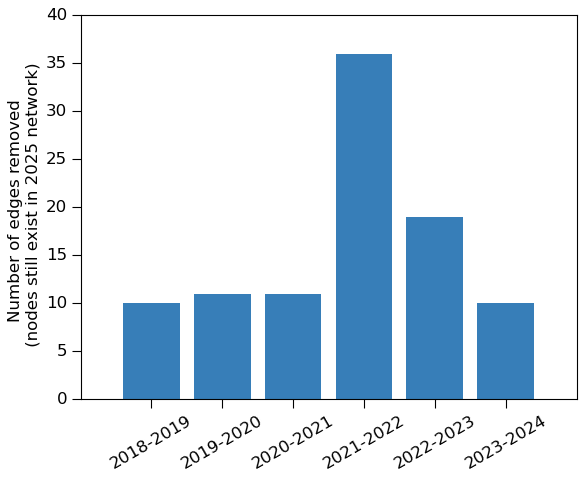

In [17]:
plt.bar([0, 1, 2, 3, 4, 5], [len(removed_edges_with_node_exist_in_2025_list[0]), len(removed_edges_with_node_exist_in_2025_list[1]), len(removed_edges_with_node_exist_in_2025_list[2]), len(removed_edges_with_node_exist_in_2025_list[3]), len(removed_edges_with_node_exist_in_2025_list[4]), len(removed_edges_with_node_exist_in_2025_list[5])])
plt.xticks([0, 1, 2, 3, 4, 5], ['2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024'])
# Rotate x-axis labels
plt.xticks(rotation=30)
plt.ylabel('Number of edges removed \n (nodes still exist in 2025 network)')
plt.show()

In [20]:
# Check if there is any removed edges that has been reassigned in the latest 2025 data
add_back_ids = []
for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    reassigned_edges = find_reassigned_edges(removed_edges, old_data_list[i], data_jul_2025, consider_interaction=False)
    print(f"From {i}th removed edges, found {len(reassigned_edges)} reassigned edges in 2025 data.")
    if len(reassigned_edges) > 0:
        print(reassigned_edges)
        for edge in reassigned_edges:
            add_back_ids.append(edge['old_signor_id'])

From 0th removed edges, found 0 reassigned edges in 2025 data.
From 1th removed edges, found 0 reassigned edges in 2025 data.
From 2th removed edges, found 1 reassigned edges in 2025 data.
[{'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}]
From 3th removed edges, found 0 reassigned edges in 2025 data.
From 4th removed edges, found 0 reassigned edges in 2025 data.
From 5th removed edges, found 0 reassigned edges in 2025 data.
From 6th removed edges, found 0 reassigned edges in 2025 data.


# Save the removed edges as a csv table

In [22]:
file_names = ['Oct2018_release', 'Oct2019_release', 'Oct2020_release', 'Oct2021_release', 'Oct2022_release', 'Oct2023_release', 'Oct2024_release', 'Jul2025_release']
data_list = [data_oct_2018, data_oct_2019, data_oct_2020, data_oct_2021, data_oct_2022, data_oct_2023, data_oct_2024, data_jul_2025]

all_removed_edges_data = []

for i, removed_edges in enumerate(removed_edges_with_node_exist_in_2025_list):
    for removed_id in removed_edges:
        old_edge_row = old_data_list[i][old_data_list[i]['SIGNOR_ID'] == removed_id]
        if not old_edge_row.empty and removed_id not in add_back_ids:
            edge_dict = old_edge_row.iloc[0].to_dict()
            edge_dict['source_release'] = file_names[i]  # Add source release column
            all_removed_edges_data.append(edge_dict)

# Create one big DataFrame with all removed edges
all_removed_edges_df = pd.DataFrame(all_removed_edges_data)

# Save to single CSV file
all_removed_edges_df.to_csv('all_removed_edges_with_sources.csv', index=False)

print(f"Saved {len(all_removed_edges_df)} removed edges to 'all_removed_edges_with_sources.csv'")

Saved 97 removed edges to 'all_removed_edges_with_sources.csv'


In [23]:
all_removed_edges_df.shape

(97, 28)

In [ ]:
# Workflow: 
# 1. I first identified the removed edges between each consecutive year by considering only SIGNOR_ID.
# 2. Since SIGNOR_IDs can change for the same edge (same ENTITYA, ENTITYB, EFFECT), I then checked whether any of the removed edges actually still existed in the following year's data with different SIGNOR_IDs.
# 3. I removed those "reassigned" edges from the removed edges list.
# 4. I then further filtered the removed edges to keep only those edges whose nodes still exist in the latest 2025 data.
# 5. Finally, I checked again whether any of the removed edges had been added back in the 2025 data.
# NOTE:
# 1. There are plenty of ribosomal subunit related edges being removed in 2021-2022 data.
# 2. There are only one removed edge being added back in 2025 data: {'old_signor_id': 'SIGNOR-170134', 'source_entity': 'TRPM7', 'target_entity': 'EEF2K', 'new_signor_id': 'SIGNOR-277923'}